**Diabetes Healthcare Data Analysis using Python, SQL and Data Visualization**

---



This project analyzes healthcare diabetes dataset using Python,
Pandas, SQLite and Matplotlib.

This project performs healthcare data analysis on diabetes dataset using Python, Pandas, SQLite and Matplotlib.

Steps included:
- Data loading
- Data exploration
- SQL storage
- SQL query analysis
- Data visualization
- OOP implementation

In [13]:
#import Libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [14]:
#Load Dataset
data =pd.read_csv("/content/diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [15]:
#Dataset Inofrmtion
print(data.info())
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                      

In [16]:
#Statistical Summary
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [17]:
##Store Data in SQL Database
conn = sqlite3.connect("diabetes.db")

data.to_sql(
    "patients",
    conn,
    if_exists="replace",
    index=False
)

768

In [18]:
#SQL Query Analysis
query = """
SELECT Outcome,
COUNT(*) as total
FROM patients
GROUP BY Outcome
"""

result = pd.read_sql(query, conn)

result

,Outcome,total
0,0,500
1,1,268


In [19]:
## SQL Query – Average Glucose by Diabetes Outcome
query2 = """
SELECT Outcome,
AVG(Glucose) as avg_glucose
FROM patients
GROUP BY Outcome
"""

result2 = pd.read_sql(query2, conn)

result2

,Outcome,avg_glucose
0,0,109.980000
1,1,141.257463


In [20]:
## SQL Query – Average BMI by Diabetes Outcome
query3 = """
SELECT Outcome,
AVG(BMI) as avg_bmi
FROM patients
GROUP BY Outcome
"""

result3 = pd.read_sql(query3, conn)

result3

,Outcome,avg_bmi
0,0,30.304200
1,1,35.142537


In [21]:
## SQL Query – Patients above age 40
query4 = """
SELECT *
FROM patients
WHERE Age > 40
"""

result4 = pd.read_sql(query4, conn)

result4.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,2,197,70,45,543,30.5,0.158,53,1
2,8,125,96,0,0,0.0,0.232,54,1
3,10,139,80,0,0,27.1,1.441,57,0
4,1,189,60,23,846,30.1,0.398,59,1


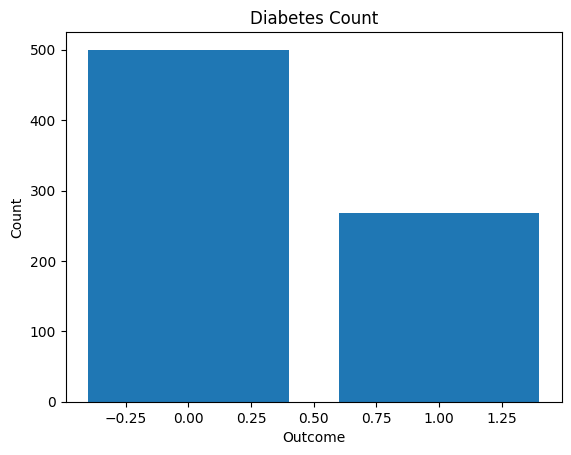

In [22]:
#Visualization-Diabetes Count

plt.bar(result["Outcome"], result["total"])

plt.xlabel("Outcome")
plt.ylabel("Count")
plt.title("Diabetes Count")

plt.show()

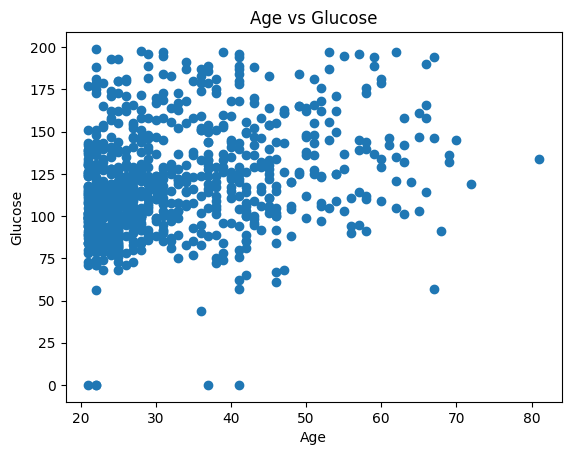

In [23]:
### Visualization – Age vs Glucose
plt.scatter(
    data["Age"],
    data["Glucose"]
)

plt.xlabel("Age")
plt.ylabel("Glucose")

plt.title("Age vs Glucose")

plt.show()

In [24]:
### OOP Implementation

class DiabetesAnalysis:

    def __init__(self, file):
        self.data = pd.read_csv(file)

    def show_info(self):
        print(self.data.info())

    def stats(self):
        print(self.data.describe())


obj = DiabetesAnalysis("diabetes.csv")

obj.show_info()

obj.stats()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

## Conclusion

This project analyzed a healthcare diabetes dataset using Python, Pandas, SQLite and Matplotlib.

The dataset was stored in a SQL database and multiple SQL queries were used to examine patient information such as glucose level, BMI and age distribution.

Visualizations helped in understanding the relationship between different medical attributes and diabetes outcome.

OOP concepts were used to create reusable analysis functions for better code structure.